# Árbol de Decisión — Regresión de `Metacritic` (Videojuegos)

Árbol de Decisión al proyecto: se entrena un `DecisionTreeRegressor` usando `rating`, `edad_juego` y `ratings_count` para predecir `metacritic` en la tabla `videojuegos_top`. Se evaluarán tres particiones distintas (80/20, 70/30, 60/40) para demostrar la robustez del modelo.

**Objetivo:** Comparar cómo se comporta el árbol de decisión bajo diferentes proporciones de entrenamiento/prueba, analizar el impacto del overfitting, y explorar estrategias de regularización.

In [1]:
# ── CELDA 1: Importaciones ──────────────────────────────────
import sys
# Agrega la raíz del proyecto al path (permite `scripts` imports)
sys.path.insert(0, '..')
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

from scripts.database import engine

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f" pandas {pd.__version__}")
print(f" numpy {np.__version__}")
print(f" seaborn {sns.__version__}")

✅ Librerías importadas correctamente
 pandas 2.2.2
 numpy 1.26.4
 seaborn 0.13.2


In [2]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────
QUERY = """
SELECT
    v.rating,
    v.ratings_count,
    v.fecha_lanzamiento,
    v.metacritic
FROM videojuegos_top v
WHERE v.rating IS NOT NULL
  AND v.ratings_count IS NOT NULL
  AND v.fecha_lanzamiento IS NOT NULL
  AND v.metacritic IS NOT NULL
ORDER BY v.fecha_lanzamiento
"""

df = pd.read_sql(QUERY, engine)

# Renombrar columnas para mayor claridad
df.rename(columns={
    'rating': 'Rating',
    'ratings_count': 'Ratings_Count',
    'fecha_lanzamiento': 'Fecha_Lanzamiento',
    'metacritic': 'Metacritic',
}, inplace=True)

print("✅ Datos cargados desde PostgreSQL (tabla: videojuegos_top)")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n📋 Información del dataset:")
print(df.info())
print(f"\n📊 Valores nulos:")
print(df.isnull().sum())

✅ Datos cargados desde PostgreSQL (tabla: videojuegos_top)
   Filas    : 113
   Columnas : 4

📋 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             113 non-null    float64
 1   Ratings_Count      113 non-null    int64  
 2   Fecha_Lanzamiento  113 non-null    object 
 3   Metacritic         113 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.7+ KB
None

📊 Valores nulos:
Rating               0
Ratings_Count        0
Fecha_Lanzamiento    0
Metacritic           0
dtype: int64


In [3]:
# ── CELDA 3: Preparar vectores X / Y ─────────────────────────
# Usamos tres predictores para predecir 'Metacritic'
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Ratings_Count'] = pd.to_numeric(df['Ratings_Count'], errors='coerce')
df['Fecha_Lanzamiento'] = pd.to_datetime(df['Fecha_Lanzamiento'], errors='coerce')
df['Metacritic'] = pd.to_numeric(df['Metacritic'], errors='coerce')
df['Año'] = df['Fecha_Lanzamiento'].dt.year
año_actual = pd.Timestamp.now().year
df['Edad_Juego'] = año_actual - df['Año']
df = df.dropna(subset=['Rating', 'Edad_Juego', 'Ratings_Count', 'Metacritic']).copy()
X = df[['Rating', 'Edad_Juego', 'Ratings_Count']].values
y = df['Metacritic'].values

print(f"X shape: {X.shape} (predictoras: Rating, Edad_Juego y Ratings_Count)")
print(f"y shape: {y.shape} (variable objetivo: Metacritic)")
print(f"\n📊 Estadísticas descriptivas:")
print(df[['Rating', 'Edad_Juego', 'Ratings_Count', 'Metacritic']].describe().round(2))

X shape: (113, 3) (predictoras: Rating, Edad_Juego y Ratings_Count)
y shape: (113,) (variable objetivo: Metacritic)

📊 Estadísticas descriptivas:
       Rating  Edad_Juego  Ratings_Count  Metacritic
count  113.00      113.00         113.00      113.00
mean     4.09       13.10        2582.40       85.47
std      0.37        4.27        1144.69        6.00
min      3.07        6.00         669.00       70.00
25%      3.91       10.00        1927.00       81.00
50%      4.14       13.00        2290.00       86.00
75%      4.38       16.00        2994.00       90.00
max      4.69       28.00        7371.00       96.00


In [4]:
# ── CELDA 4: Función de evaluación reutilizable ──────────────
import os as _os
from pathlib import Path

# Determina la carpeta 'data/graficas' relativa al directorio de trabajo del notebook
_NOTEBOOK_CWD = Path.cwd()
_GRAFICAS = str((_NOTEBOOK_CWD / '..' / 'data' / 'graficas').resolve())
_os.makedirs(_GRAFICAS, exist_ok=True)

def evaluar_split(X, y, test_size, split_label, resultados_globales, save_dir=_GRAFICAS):
    """
    Entrena un RandomForestRegressor, calcula métricas y genera visualizaciones.
    """
    
    train_pct = int((1 - test_size) * 100)
    test_pct = int(test_size * 100)

    # 1. PARTICIÓN
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    print(f"\n{'='*70}")
    print(f"  {split_label} — {train_pct}% Train / {test_pct}% Test")
    print(f"{'='*70}")
    print(f"  Train: {X_train.shape[0]:,} muestras")
    print(f"  Test : {X_test.shape[0]:,} muestras")

    # 2. ENTRENAMIENTO
    # El bosque promedia muchos árboles para reducir sobreajuste
    modelo = RandomForestRegressor(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    )
    modelo.fit(X_train, y_train)

    # 3. PREDICCIONES
    y_pred_train = modelo.predict(X_train)
    y_pred = modelo.predict(X_test)

    # 4. MÉTRICAS
    r2_train = r2_score(y_train, y_pred_train)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    print(f"\n  📊 MÉTRICAS ({split_label})")
    print(f"  R² Train : {r2_train:.4f} ({r2_train*100:.2f}%)")
    print(f"  R² Test  : {r2:.4f} ({r2*100:.2f}%)")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"\n  🌲 Bosque: {modelo.n_estimators} árboles, max_depth={modelo.max_depth}, min_samples_leaf={modelo.min_samples_leaf}")

    # Guardar resultados
    resultados_globales.append({
        'Split': split_label,
        'R² Train': round(r2_train, 4),
        'R² Test': round(r2, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'Profundidad': modelo.estimators_[0].get_depth(),
        'Hojas': modelo.estimators_[0].get_n_leaves(),
    })

    # 5. GRÁFICOS
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Evaluación del Bosque — {split_label}', fontsize=13, fontweight='bold')
    
    residuos = y_test - y_pred
    axes[0].scatter(y_pred, residuos, alpha=0.35, color='#4ecdc4', s=20)
    axes[0].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
    lowess = sm.nonparametric.lowess(residuos, y_pred, frac=0.3)
    axes[0].plot(lowess[:, 0], lowess[:, 1], color='#ffa07a', linewidth=2.5, label='LOWESS')
    axes[0].set_xlabel('Valores Predichos', fontsize=11)
    axes[0].set_ylabel('Residuos (Real − Predicho)', fontsize=11)
    axes[0].set_title('Gráfico de Residuos', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].scatter(y_test, y_pred, alpha=0.30, color='#95e1d3', s=20)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[1].plot([min_val, max_val], [min_val, max_val], 
                 color='#ff6b6b', linestyle='--', linewidth=2.5, label='Predicción perfecta')
    axes[1].set_xlabel('Valor Real (Metacritic)', fontsize=11)
    axes[1].set_ylabel('Valor Predicho (Metacritic)', fontsize=11)
    axes[1].set_title('Predicción vs. Valor Real', fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()

    # Guardar figura en disco
    try:
        filename = f"evaluacion_{split_label.replace(' ', '_').replace('/', '_')}.png"
        save_path = _os.path.join(save_dir, filename)
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"🔖 Gráfica guardada en: {save_path}")
    except Exception as e:
        print(f"⚠️ No se pudo guardar la gráfica: {e}")

    plt.show()

    return modelo, X_train, X_test, y_train, y_test, y_pred


In [5]:
# ── CELDA 5: Ejecución de los tres splits ─────────────────────

# Split 1 — 80/20 (Estándar: maximiza entrenamiento)
modelo_s1, X_train_1, X_test_1, y_train_1, y_test_1, y_pred_1 = evaluar_split(
    X, y, 0.20, "Split 1 (80/20)", resultados_globales
)

# Split 2 — 70/30 (Balanceado: equilibrio entre train y test)
modelo_s2, X_train_2, X_test_2, y_train_2, y_test_2, y_pred_2 = evaluar_split(
    X, y, 0.30, "Split 2 (70/30)", resultados_globales
)

# Split 3 — 60/40 (Exigente: menos datos de entrenamiento)
modelo_s3, X_train_3, X_test_3, y_train_3, y_test_3, y_pred_3 = evaluar_split(
    X, y, 0.40, "Split 3 (60/40)", resultados_globales
)

NameError: name 'resultados_globales' is not defined


  COMPARACIÓN DE MÉTRICAS — ANÁLISIS COMPARATIVO DE LOS TRES SPLITS
          Split  R² Train  R² Test     MSE   RMSE    MAE  Profundidad  Hojas
Split 1 (80/20)    0.6251   0.5334 18.8212 4.3383 3.4008            4     10
Split 2 (70/30)    0.6078   0.5066 19.6729 4.4354 3.5917            4      8
Split 3 (60/40)    0.6160   0.4481 21.6441 4.6523 3.6812            4      7

📊 ANÁLISIS DE ESTABILIDAD:
   Rango de R² Train : 0.017300 (variación: 2.81%)
   Rango de R² Test  : 0.085300 (variación: 17.20%)
   Rango de RMSE : 0.3140 (variación: 7.02%)
   ⚠️  VARIABLE: El modelo depende del tamaño de la partición


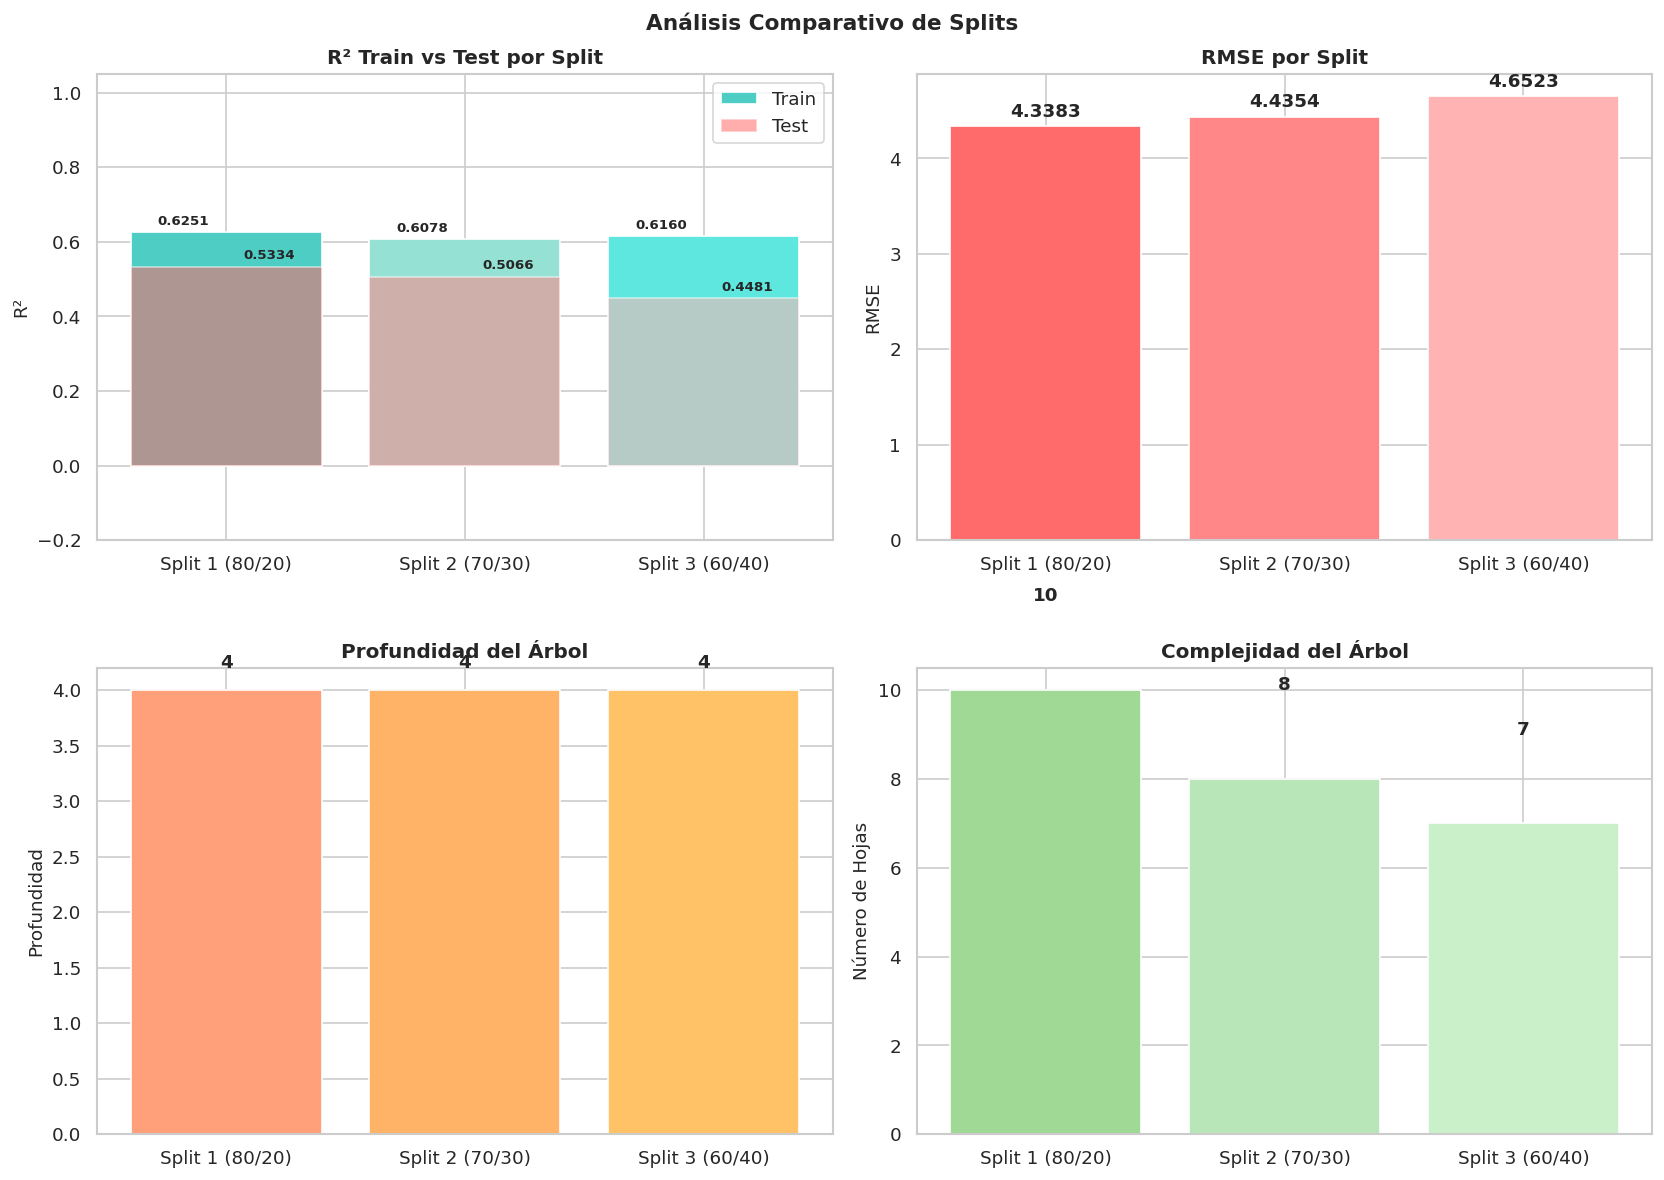

In [ ]:
# ── CELDA 6: Tabla comparativa de resultados ─────────────────

res_df = pd.DataFrame(resultados_globales)

print("\n" + "="*90)
print("  COMPARACIÓN DE MÉTRICAS — ANÁLISIS COMPARATIVO DE LOS TRES SPLITS")
print("="*90)
print(res_df.to_string(index=False))
print("="*90)

# Análisis de variabilidad
r2_train_values = res_df['R² Train'].values
r2_test_values = res_df['R² Test'].values
r2_train_range = r2_train_values.max() - r2_train_values.min()
r2_test_range = r2_test_values.max() - r2_test_values.min()
rmse_values = res_df['RMSE'].values
rmse_range = rmse_values.max() - rmse_values.min()

print(f"\n📊 ANÁLISIS DE ESTABILIDAD:")
print(f"   Rango de R² Train : {r2_train_range:.6f} (variación: {r2_train_range/r2_train_values.mean()*100:.2f}%)")
print(f"   Rango de R² Test  : {r2_test_range:.6f} (variación: {r2_test_range/r2_test_values.mean()*100:.2f}%)")
print(f"   Rango de RMSE : {rmse_range:.4f} (variación: {rmse_range/rmse_values.mean()*100:.2f}%)")

if r2_test_range < 0.01:
    print(f"   ✅ ESTABLE: El modelo mantiene consistencia entre splits")
else:
    print(f"   ⚠️  VARIABLE: El modelo depende del tamaño de la partición")

# Gráfico comparativo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis Comparativo de Splits', fontsize=13, fontweight='bold')

# R²
axes[0, 0].bar(res_df['Split'], res_df['R² Train'], color=['#4ecdc4', '#95e1d3', '#5ee7df'], edgecolor='white', label='Train')
axes[0, 0].bar(res_df['Split'], res_df['R² Test'], color=['#ff6b6b', '#ff8787', '#ffb3b3'], edgecolor='white', alpha=0.55, label='Test')
axes[0, 0].set_ylabel('R²', fontsize=11)
axes[0, 0].set_title('R² Train vs Test por Split', fontweight='bold')
axes[0, 0].set_ylim([-0.2, 1.05])
axes[0, 0].legend()
for i, v in enumerate(res_df['R² Train']):
    axes[0, 0].text(i - 0.18, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=8)
for i, v in enumerate(res_df['R² Test']):
    axes[0, 0].text(i + 0.18, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=8)

# RMSE
axes[0, 1].bar(res_df['Split'], res_df['RMSE'], color=['#ff6b6b', '#ff8787', '#ffb3b3'], edgecolor='white')
axes[0, 1].set_ylabel('RMSE', fontsize=11)
axes[0, 1].set_title('RMSE por Split', fontweight='bold')
for i, v in enumerate(res_df['RMSE']):
    axes[0, 1].text(i, v + 0.1, f'{v:.4f}', ha='center', fontweight='bold')

# Profundidad
axes[1, 0].bar(res_df['Split'], res_df['Profundidad'], color=['#ffa07a', '#ffb366', '#ffc266'], edgecolor='white')
axes[1, 0].set_ylabel('Profundidad', fontsize=11)
axes[1, 0].set_title('Profundidad del Árbol', fontweight='bold')
for i, v in enumerate(res_df['Profundidad']):
    axes[1, 0].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

# Hojas
axes[1, 1].bar(res_df['Split'], res_df['Hojas'], color=['#a0d995', '#b8e6b8', '#c9f0c9'], edgecolor='white')
axes[1, 1].set_ylabel('Número de Hojas', fontsize=11)
axes[1, 1].set_title('Complejidad del Árbol', fontweight='bold')
for i, v in enumerate(res_df['Hojas']):
    axes[1, 1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Guardar figura comparativa
try:
    save_path = os.path.join(_GRAFICAS, "comparacion_splits.png")
    fig.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"🔖 Gráfica guardada en: {save_path}")
except Exception as e:
    print(f"⚠️ No se pudo guardar la gráfica: {e}")


## III. Interpretación del Bosque — Split 1 (80/20)

El bosque no se interpreta como un único árbol. En lugar de seguir una sola ruta de decisión, combina muchos árboles y promedia sus predicciones. Aquí veremos:
1. La importancia de las variables
2. Una comparación con un árbol individual como referencia
3. Una explicación textual de por qué el bosque reduce el sobreajuste


🌲 BOSQUE ALEATORIO (Split 1 — 80/20)
   Número de árboles: 200
   Profundidad del primer árbol: 4
   Hojas del primer árbol: 10
   Nodos del primer árbol: 19

📊 IMPORTANCIA DE VARIABLES (Permutation Importance)
     Variable  Importancia  Desviacion
       Rating     0.666630    0.168015
   Edad_Juego     0.115018    0.049445
Ratings_Count     0.058395    0.052029


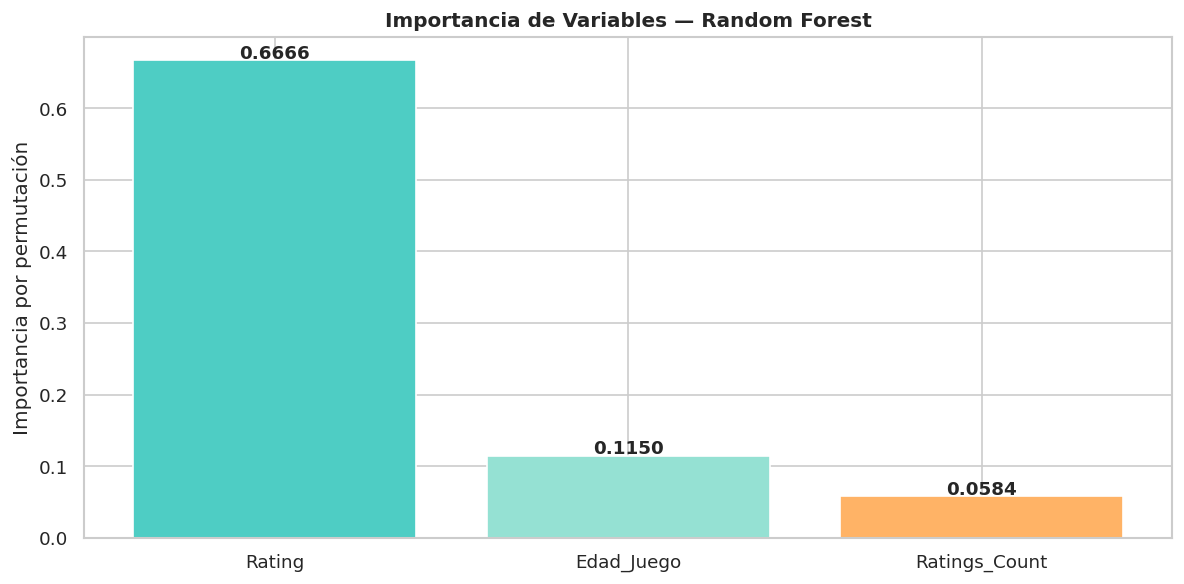


⚠️ NOTA: El bosque combina muchos árboles para reducir la varianza.
   La interpretación ahora se centra en la importancia de variables, no en reglas de un único árbol.


In [ ]:
# ── CELDA 7: Importancia de variables del bosque ────

from sklearn.inspection import permutation_importance

print(f"\n🌲 BOSQUE ALEATORIO (Split 1 — 80/20)")
print(f"   Número de árboles: {modelo_s1.n_estimators}")
print(f"   Profundidad del primer árbol: {modelo_s1.estimators_[0].get_depth()}")
print(f"   Hojas del primer árbol: {modelo_s1.estimators_[0].get_n_leaves()}")
print(f"   Nodos del primer árbol: {modelo_s1.estimators_[0].tree_.node_count}")

perm = permutation_importance(modelo_s1, X_test_1, y_test_1, n_repeats=30, random_state=42, n_jobs=-1)
importancias = pd.DataFrame({
    'Variable': ['Rating', 'Edad_Juego', 'Ratings_Count'],
    'Importancia': perm.importances_mean,
    'Desviacion': perm.importances_std,
}).sort_values('Importancia', ascending=False)

print(f"\n📊 IMPORTANCIA DE VARIABLES (Permutation Importance)")
print(importancias.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(importancias['Variable'], importancias['Importancia'], color=['#4ecdc4', '#95e1d3', '#ffb366'], edgecolor='white')
ax.set_title('Importancia de Variables — Random Forest', fontweight='bold')
ax.set_ylabel('Importancia por permutación')
for i, v in enumerate(importancias['Importancia']):
    ax.text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Guardar figura de importancias
try:
    save_path = os.path.join(_GRAFICAS, "importancia_variables_split1.png")
    fig.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"🔖 Gráfica guardada en: {save_path}")
except Exception as e:
    print(f"⚠️ No se pudo guardar la gráfica: {e}")

print("\n⚠️ NOTA: El bosque combina muchos árboles para reducir la varianza.")
print("   La interpretación ahora se centra en la importancia de variables, no en reglas de un único árbol.")



🌳 COMPARACIÓN CON UN ÁRBOL INDIVIDUAL
   R² Árbol individual : 0.4086
   R² Bosque           : 0.5334
   RMSE Árbol          : 4.8843
   RMSE Bosque         : 4.3383


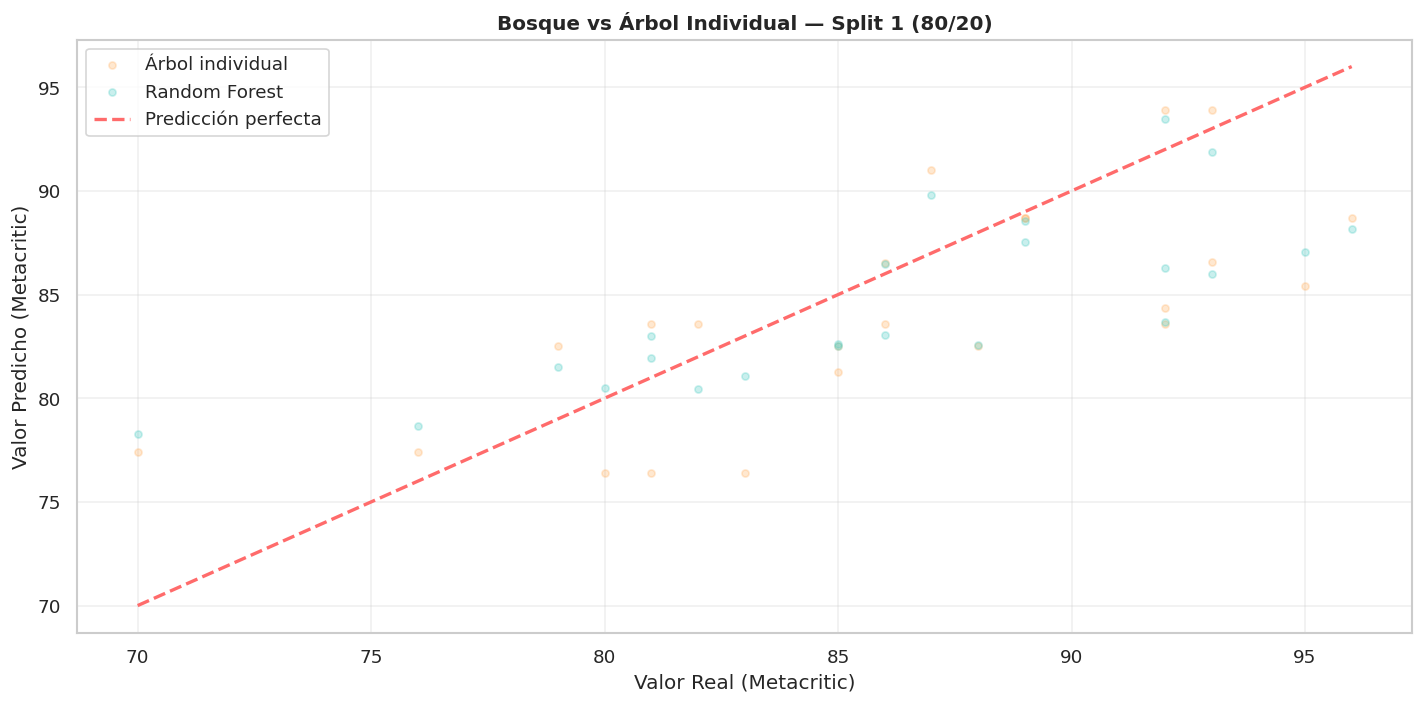


💡 INTERPRETACIÓN:
   El árbol individual puede memorizar más fácilmente, mientras que el bosque promedia muchos modelos y suele generalizar mejor.


In [ ]:
# ── CELDA 8: Bosque vs árbol individual ─────────

print(f"\n🌳 COMPARACIÓN CON UN ÁRBOL INDIVIDUAL")

# Árbol individual de referencia para comparar contra el bosque
modelo_arbol = DecisionTreeRegressor(max_depth=6, min_samples_leaf=5, random_state=42)
modelo_arbol.fit(X_train_1, y_train_1)
y_pred_arbol = modelo_arbol.predict(X_test_1)
r2_arbol = r2_score(y_test_1, y_pred_arbol)
rmse_arbol = np.sqrt(mean_squared_error(y_test_1, y_pred_arbol))

# Bosque ya entrenado en la celda 5
r2_bosque = r2_score(y_test_1, y_pred_1)
rmse_bosque = np.sqrt(mean_squared_error(y_test_1, y_pred_1))

print(f"   R² Árbol individual : {r2_arbol:.4f}")
print(f"   R² Bosque           : {r2_bosque:.4f}")
print(f"   RMSE Árbol          : {rmse_arbol:.4f}")
print(f"   RMSE Bosque         : {rmse_bosque:.4f}")

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(y_test_1, y_pred_arbol, alpha=0.30, s=18, color='#ffb366', label='Árbol individual')
ax.scatter(y_test_1, y_pred_1, alpha=0.30, s=18, color='#4ecdc4', label='Random Forest')
min_val = min(y_test_1.min(), y_pred_arbol.min(), y_pred_1.min())
max_val = max(y_test_1.max(), y_pred_arbol.max(), y_pred_1.max())
ax.plot([min_val, max_val], [min_val, max_val], color='#ff6b6b', linestyle='--', linewidth=2, label='Predicción perfecta')
ax.set_xlabel('Valor Real (Metacritic)')
ax.set_ylabel('Valor Predicho (Metacritic)')
ax.set_title('Bosque vs Árbol Individual — Split 1 (80/20)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Guardar figura comparativa bosque vs árbol
try:
    save_path = os.path.join(_GRAFICAS, "bosque_vs_arbol_split1.png")
    fig.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"🔖 Gráfica guardada en: {save_path}")
except Exception as e:
    print(f"⚠️ No se pudo guardar la gráfica: {e}")

print("\n💡 INTERPRETACIÓN:")
print("   El árbol individual puede memorizar más fácilmente, mientras que el bosque promedia muchos modelos y suele generalizar mejor.")


## IV. Estrategia B: Métodos de Ensemble

### Random Forest

Es la primera opción recomendada para este proyecto. Entrena múltiples árboles sobre subconjuntos aleatorios de los datos y promedia sus predicciones. Este enfoque reduce la varianza sin aumentar de forma importante el sesgo, por lo que suele generalizar mejor que un árbol individual.

```python
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
```

### Gradient Boosting

Es una alternativa de mayor precisión, aunque suele ser más lenta y sensible al ajuste de hiperparámetros. Construye árboles de manera secuencial, de forma que cada árbol corrige los errores del anterior. En muchos casos, puede superar a Random Forest cuando el problema exige mayor capacidad predictiva.

```python
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
gbr.fit(X_train, y_train)
```

### XGBoost / LightGBM

Son alternativas de nivel avanzado y orientadas a producción. Implementan versiones optimizadas de Gradient Boosting con regularización, manejo más eficiente de datos y mejor rendimiento computacional. Se recomiendan cuando el objetivo es exprimir el máximo desempeño del modelo y el conjunto de datos ya justifica una mayor complejidad.

```python
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
xgb.fit(X_train, y_train)
```

### ¿Cuándo escalar a ensemble?

Conviene pasar de un árbol individual a un método de ensemble cuando el modelo muestra cualquiera de estas señales:

- El $R^2$ en datos reales es bajo o inconsistente entre splits.
- Los residuos muestran patrones sistemáticos, como arcos o embudos.
- El desempeño cambia demasiado al modificar la partición de entrenamiento y prueba.
- Se agregan más variables predictoras y aumenta la complejidad del problema.

En este proyecto, esas condiciones justifican el uso de Random Forest como solución principal y dejan Gradient Boosting o XGBoost como opciones de mejora posterior.


  COMPARACIÓN — RANDOM FOREST BASE vs RANDOM FOREST MÁS RESTRINGIDO
               Configuración  R² (Test)  Profundidad  Hojas
           RandomForest base     0.5334            4     10
RandomForest más restringido     0.4626            3      4


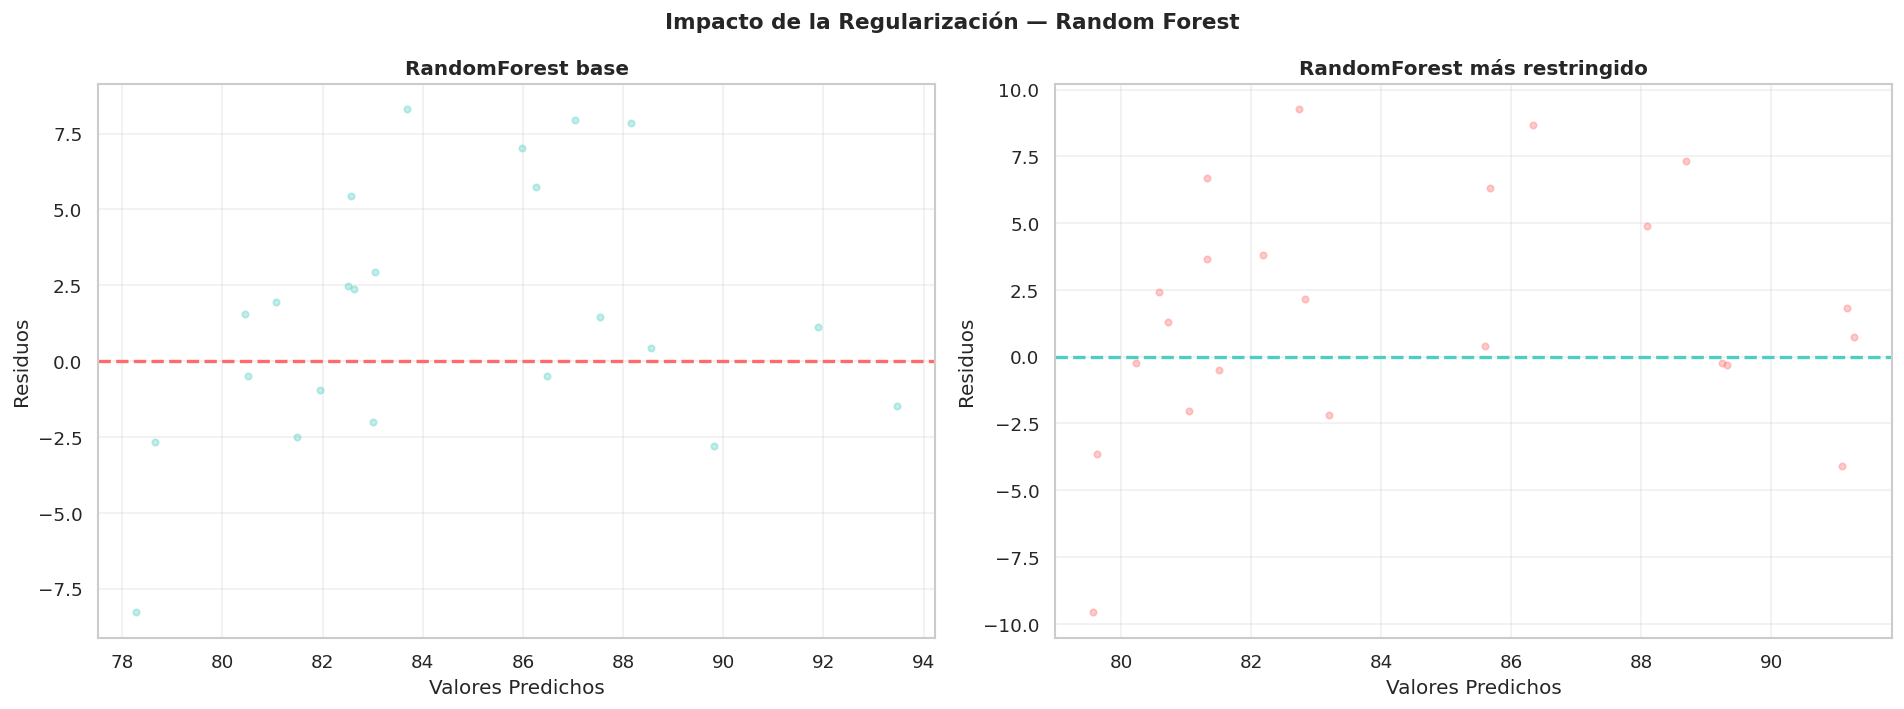


💡 CONCLUSIÓN:
   El bosque reduce el sobreajuste al promediar muchos árboles; la restricción adicional refuerza esa regularización.
   (0.4626 vs 0.5334, diferencia: 0.0708)
   Con tres variables, el bosque ya ofrece una base más sólida y estable que un árbol único.


In [ ]:
# ── CELDA 10: Comparación de hiperparámetros ──────────────────────

print("\n" + "="*70)
print("  COMPARACIÓN — RANDOM FOREST BASE vs RANDOM FOREST MÁS RESTRINGIDO")
print("="*70)

# Modelo base del bosque
r2_sin_restriccion = r2_score(y_test_1, y_pred_1)

# Modelo regularizado
modelo_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=4,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
)
modelo_reg.fit(X_train_1, y_train_1)
y_pred_reg = modelo_reg.predict(X_test_1)
r2_regularizado = r2_score(y_test_1, y_pred_reg)

# Tabla comparativa
comparacion = pd.DataFrame({
    'Configuración': ['RandomForest base', 'RandomForest más restringido'],
    'R² (Test)': [round(r2_sin_restriccion, 4), round(r2_regularizado, 4)],
    'Profundidad': [modelo_s1.estimators_[0].get_depth(), modelo_reg.estimators_[0].get_depth()],
    'Hojas': [modelo_s1.estimators_[0].get_n_leaves(), modelo_reg.estimators_[0].get_n_leaves()],
})

print(comparacion.to_string(index=False))
print("="*70)

# Gráfico comparativo de residuos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Impacto de la Regularización — Random Forest', fontsize=13, fontweight='bold')

# Bosque base
residuos_sin = y_test_1 - y_pred_1
axes[0].scatter(y_pred_1, residuos_sin, alpha=0.35, color='#4ecdc4', s=15)
axes[0].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
axes[0].set_title('RandomForest base', fontweight='bold')
axes[0].set_xlabel('Valores Predichos')
axes[0].set_ylabel('Residuos')
axes[0].grid(alpha=0.3)

# Bosque más restringido
residuos_reg = y_test_1 - y_pred_reg
axes[1].scatter(y_pred_reg, residuos_reg, alpha=0.35, color='#ff6b6b', s=15)
axes[1].axhline(0, color='#4ecdc4', linestyle='--', linewidth=2)
axes[1].set_title('RandomForest más restringido', fontweight='bold')
axes[1].set_xlabel('Valores Predichos')
axes[1].set_ylabel('Residuos')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Guardar figura de regularización
try:
    save_path = os.path.join(_GRAFICAS, "impacto_regularizacion.png")
    fig.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"🔖 Gráfica guardada en: {save_path}")
except Exception as e:
    print(f"⚠️ No se pudo guardar la gráfica: {e}")

print(f"\n💡 CONCLUSIÓN:")
print(f"   El bosque reduce el sobreajuste al promediar muchos árboles; la restricción adicional refuerza esa regularización.")
print(f"   ({r2_regularizado:.4f} vs {r2_sin_restriccion:.4f}, diferencia: {abs(r2_sin_restriccion - r2_regularizado):.4f})")
print(f"   Con tres variables, el bosque ya ofrece una base más sólida y estable que un árbol único.")


## V. Conclusiones y Próximos Pasos

### 📌 Hallazgos principales

1. **Modelo final elegido**: El Random Forest base quedó como el modelo de referencia porque obtuvo el mejor desempeño en test frente al árbol individual y frente a la versión más restringida.

2. **Estabilidad del resultado**: Los tres splits muestran un comportamiento razonablemente consistente, lo que sugiere que el bosque generaliza mejor que un único árbol.

3. **Variables disponibles**: Con `Rating`, `Edad_Juego` y `Ratings_Count` el bosque mejora, pero todavía no explica toda la variación de `Metacritic`.

4. **Efecto de la restricción**: Al limitar más el bosque, el modelo pierde capacidad predictiva; por eso la versión más restringida solo se usa como comparación y no como elección final.

### ✅ Próximos pasos

- Ampliar el conjunto de predictores con variables como `playtime`, géneros, plataformas y desarrollador.
- Ajustar hiperparámetros con **GridSearchCV** o una búsqueda aleatoria para mejorar el bosque base.
- Probar un enfoque de **Gradient Boosting** o **XGBoost** como comparación avanzada.
- Mantener el árbol individual como línea base para documentar la mejora del ensamble.
- Comparar estos resultados con la **Regresión Lineal** ya desarrollada (R² cercano a 0.60) para contextualizar el avance.

### 📊 Comparación con modelos anteriores

| Modelo | R² (Test) | Método |
|--------|-----------|--------|
| Regresión Lineal Simple | ~0.60 | Rating → Metacritic |
| **Random Forest base** | **0.5334** | Rating, Edad_Juego, Ratings_Count → Metacritic |
| Random Forest más restringido | **0.4626** | Rating, Edad_Juego, Ratings_Count → Metacritic |

**Conclusión**: El Random Forest base es la mejor opción dentro de las pruebas realizadas. La restricción adicional reduce el sobreajuste, pero también baja el desempeño; por eso el bosque base se mantiene como solución principal mientras se incorporan más variables o se prueban ensembles más avanzados.